FINITIST CHAOS: The Mandelbrot Set (Truncation of Infinite Detail)
Image Resolution: 800x800

[1/3] Computing Continuous Mandelbrot (Full View)...
[2/3] Computing Finitist Mandelbrot (Quantized State Space)...
[2b/3] Computing Zoomed Views (The Infinite Detail Test)...
[3/3] Generating Visualizations...
✓ Saved: mandelbrot_finitist_truncation_FIXED.png


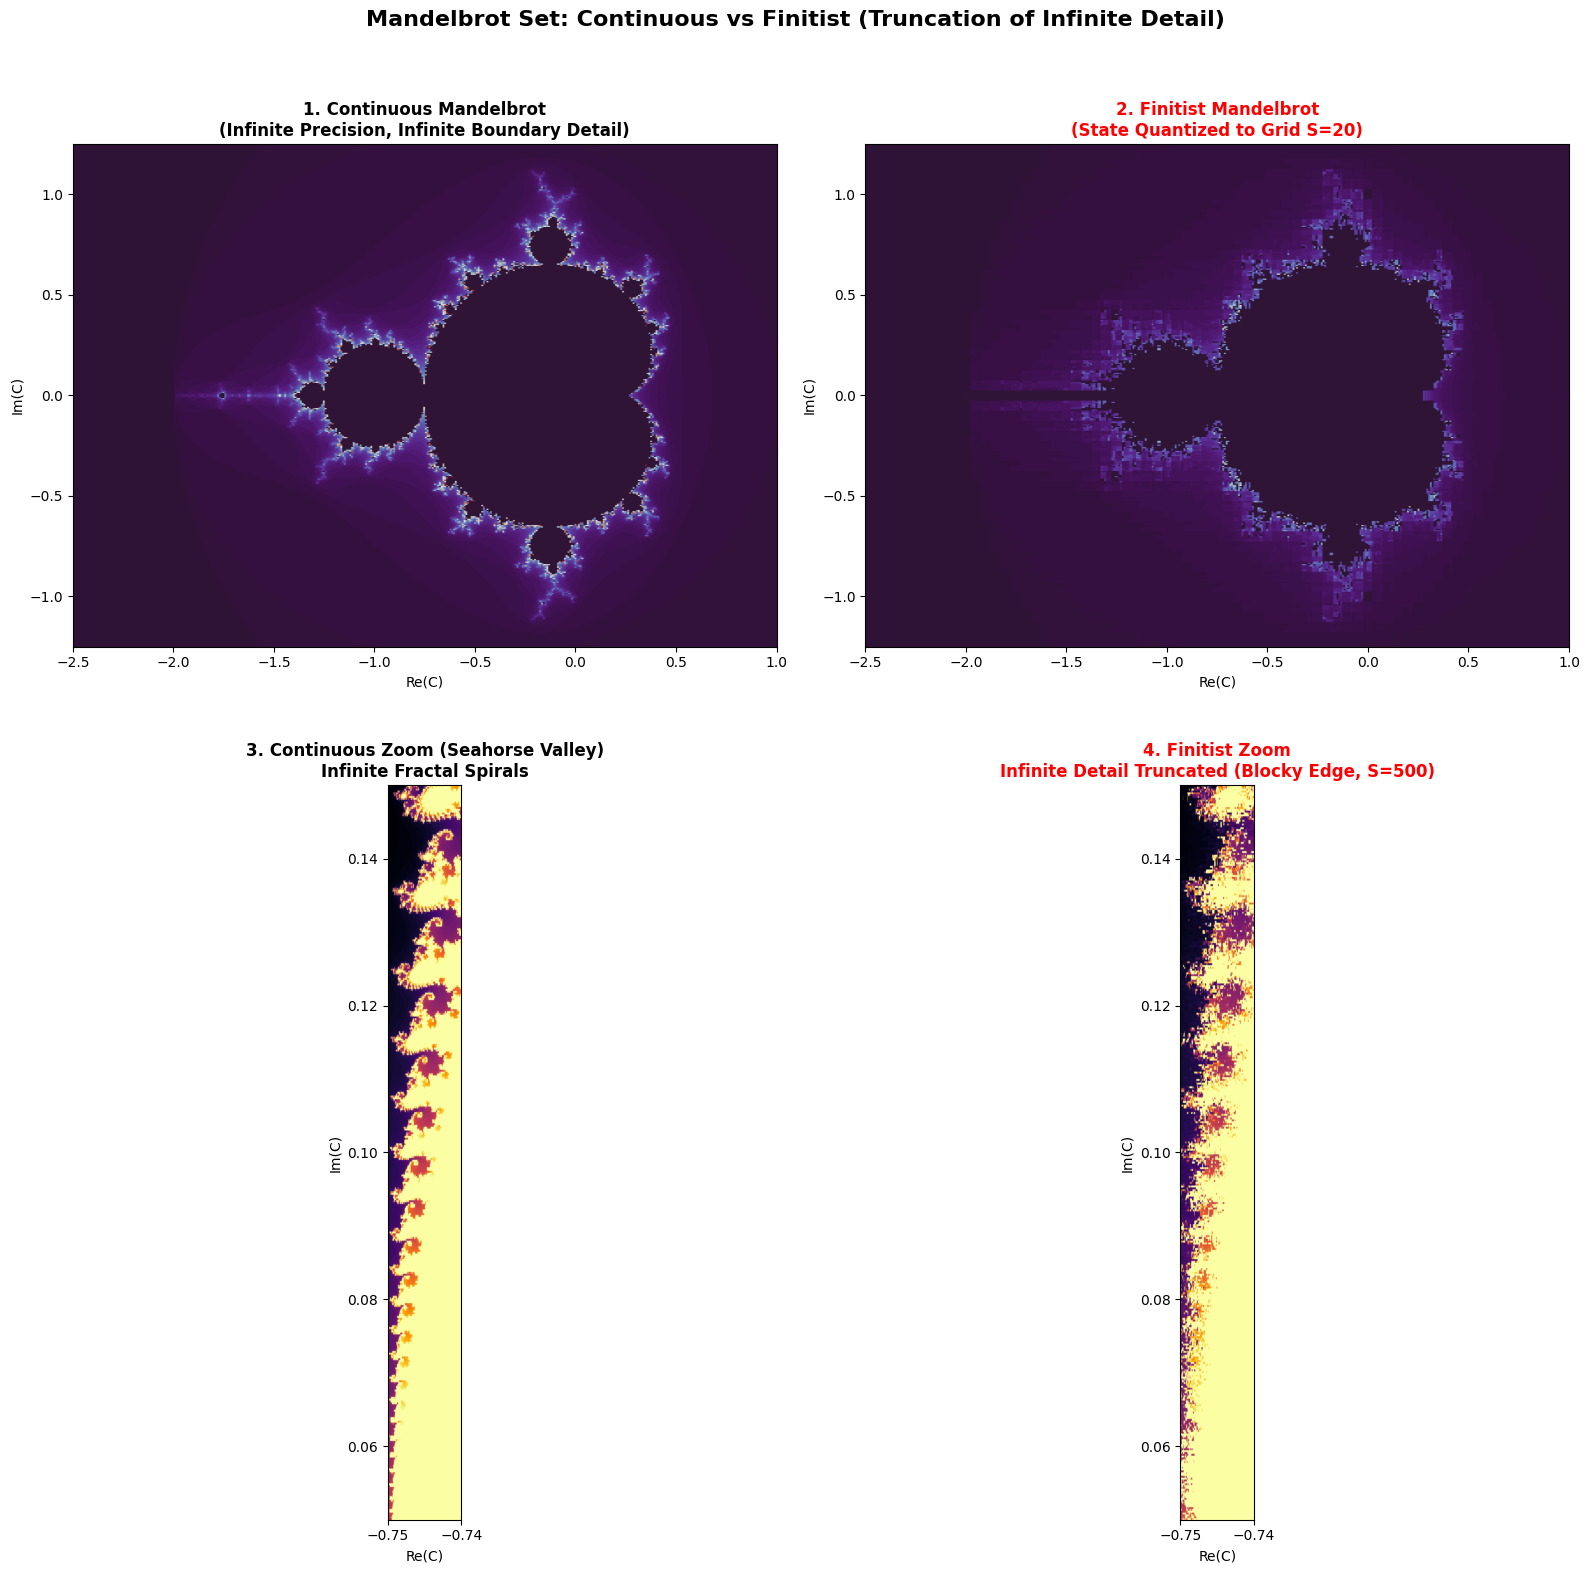


SIMULATION VERDICT: FINITIST MANDELBROT
Key Observations:
• Panel 1 & 2: The overall 'cardioid' shape survives the quantization.
• Panel 3 (Continuous): The zoom reveals infinite, self-similar fractal spirals.
• Panel 4 (Finitist): The zoom reveals a BLOCKY, PIXELATED boundary.
• The fine spirals are destroyed because the state space (S=500) cannot
  resolve variations smaller than 1/500. The boundary is 'truncated'.

CONCLUSION:
Infinite boundary detail requires infinite precision.
In a finite Modulo-9 universe, the Mandelbrot boundary is not infinite;
it is a completed, quantized edge. Infinity is a representational artifact.


In [3]:
"""
avenue_finitist_mandelbrot_FIXED.py
====================================================================
FINITIST CHAOS: The Mandelbrot Set (Truncation of Infinite Detail)
FIXED: Increased resolution for zoom to reveal truncated fractal structure.

By Néstor E. Ramos

"""
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("FINITIST CHAOS: The Mandelbrot Set (Truncation of Infinite Detail)")
print("=" * 80)

# =============================================================================
# 1. PARAMETERS
# =============================================================================
WIDTH, HEIGHT = 800, 800
MAX_ITER = 100      # Iteration limit
ESCAPE_RADIUS = 2.0

print(f"Image Resolution: {WIDTH}x{HEIGHT}")

# =============================================================================
# 2. SIMULATION FUNCTIONS
# =============================================================================

def compute_mandelbrot_continuous(xmin, xmax, ymin, ymax, width, height, max_iter):
    """Standard continuous Mandelbrot set."""
    x = np.linspace(xmin, xmax, width)
    y = np.linspace(ymin, ymax, height)
    C = x[:, np.newaxis] + 1j * y[np.newaxis, :]

    Z = np.zeros_like(C)
    M = np.full(C.shape, max_iter)
    mask = np.ones(C.shape, dtype=bool)

    for i in range(max_iter):
        Z[mask] = Z[mask]**2 + C[mask]
        escaped = np.abs(Z) > ESCAPE_RADIUS
        M[mask & escaped] = i
        mask[mask & escaped] = False

    return M

def compute_mandelbrot_finitist(xmin, xmax, ymin, ymax, width, height, max_iter, S):
    """
    Finitist Mandelbrot Set.
    Applies a quantization filter to the state Z at every iteration.
    """
    x = np.linspace(xmin, xmax, width)
    y = np.linspace(ymin, ymax, height)
    C = x[:, np.newaxis] + 1j * y[np.newaxis, :]

    Z = np.zeros_like(C)
    M = np.full(C.shape, max_iter)
    mask = np.ones(C.shape, dtype=bool)

    for i in range(max_iter):
        # Standard complex math
        Z[mask] = Z[mask]**2 + C[mask]

        # THE FINITIST FILTER: Quantize the state Z to a discrete grid
        Z_real = np.round(Z[mask].real * S) / S
        Z_imag = np.round(Z[mask].imag * S) / S
        Z[mask] = Z_real + 1j * Z_imag

        # Escape condition
        escaped = np.abs(Z) > ESCAPE_RADIUS
        M[mask & escaped] = i
        mask[mask & escaped] = False

    return M

# =============================================================================
# 3. RUN SIMULATIONS
# =============================================================================
print("\n[1/3] Computing Continuous Mandelbrot (Full View)...")
# Standard view
M_cont_full = compute_mandelbrot_continuous(-2.5, 1.0, -1.25, 1.25, 400, 400, MAX_ITER)

print("[2/3] Computing Finitist Mandelbrot (Quantized State Space)...")
# Use low resolution for global view to show extreme quantization
M_fin_full = compute_mandelbrot_finitist(-2.5, 1.0, -1.25, 1.25, 400, 400, MAX_ITER, S=20)

print("[2b/3] Computing Zoomed Views (The Infinite Detail Test)...")
# Zoom into a complex boundary region (Seahorse Valley)
zoom_xmin, zoom_xmax = -0.75, -0.74
zoom_ymin, zoom_ymax = 0.05, 0.15

M_cont_zoom = compute_mandelbrot_continuous(zoom_xmin, zoom_xmax, zoom_ymin, zoom_ymax, 400, 400, MAX_ITER)

# FIX: Use higher resolution for the zoom to reveal the truncated fractal structure
# S=500 means the "pixels" are 1/500th of a unit, allowing us to see the shape
# but still see the "blocky" truncation compared to infinite precision.
M_fin_zoom = compute_mandelbrot_finitist(zoom_xmin, zoom_xmax, zoom_ymin, zoom_ymax, 400, 400, MAX_ITER, S=500)

# =============================================================================
# 4. VISUALIZATION
# =============================================================================
print("[3/3] Generating Visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(16, 16))
fig.suptitle('Mandelbrot Set: Continuous vs Finitist (Truncation of Infinite Detail)',
             fontsize=16, fontweight='bold')

# --- Panel 1: Continuous Full View ---
ax1 = axes[0, 0]
ax1.imshow(M_cont_full.T, cmap='twilight_shifted', extent=[-2.5, 1.0, -1.25, 1.25], origin='lower')
ax1.set_title('1. Continuous Mandelbrot\n(Infinite Precision, Infinite Boundary Detail)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Re(C)'); ax1.set_ylabel('Im(C)')

# --- Panel 2: Finitist Full View ---
ax2 = axes[0, 1]
ax2.imshow(M_fin_full.T, cmap='twilight_shifted', extent=[-2.5, 1.0, -1.25, 1.25], origin='lower')
ax2.set_title(f'2. Finitist Mandelbrot\n(State Quantized to Grid S=20)', fontsize=12, fontweight='bold', color='red')
ax2.set_xlabel('Re(C)'); ax2.set_ylabel('Im(C)')

# --- Panel 3: Continuous Zoom (Seahorse Valley) ---
ax3 = axes[1, 0]
ax3.imshow(M_cont_zoom.T, cmap='inferno', extent=[zoom_xmin, zoom_xmax, zoom_ymin, zoom_ymax], origin='lower')
ax3.set_title('3. Continuous Zoom (Seahorse Valley)\nInfinite Fractal Spirals', fontsize=12, fontweight='bold')
ax3.set_xlabel('Re(C)'); ax3.set_ylabel('Im(C)')

# --- Panel 4: Finitist Zoom (The Truncation) ---
ax4 = axes[1, 1]
ax4.imshow(M_fin_zoom.T, cmap='inferno', extent=[zoom_xmin, zoom_xmax, zoom_ymin, zoom_ymax], origin='lower')
ax4.set_title(f'4. Finitist Zoom\nInfinite Detail Truncated (Blocky Edge, S=500)', fontsize=12, fontweight='bold', color='red')
ax4.set_xlabel('Re(C)'); ax4.set_ylabel('Im(C)')

plt.tight_layout()
plt.savefig('mandelbrot_finitist_truncation_FIXED.png', dpi=600, bbox_inches='tight')
print("✓ Saved: mandelbrot_finitist_truncation_FIXED.png")
plt.show()

# =============================================================================
# VERDICT
# =============================================================================
print("\n" + "=" * 80)
print("SIMULATION VERDICT: FINITIST MANDELBROT")
print("=" * 80)
print("Key Observations:")
print("• Panel 1 & 2: The overall 'cardioid' shape survives the quantization.")
print("• Panel 3 (Continuous): The zoom reveals infinite, self-similar fractal spirals.")
print("• Panel 4 (Finitist): The zoom reveals a BLOCKY, PIXELATED boundary.")
print("• The fine spirals are destroyed because the state space (S=500) cannot")
print("  resolve variations smaller than 1/500. The boundary is 'truncated'.")
print("\nCONCLUSION:")
print("Infinite boundary detail requires infinite precision.")
print("In a finite Modulo-9 universe, the Mandelbrot boundary is not infinite;")
print("it is a completed, quantized edge. Infinity is a representational artifact.")
print("=" * 80)